# ENVIRONMENT NOTE:
This code was developed using Google Colab, which provides built-in support for Google Drive mounting and cloud-based file handling. As a result, some components (e.g., `google.colab.drive.mount`) are not compatible with local development environments such as VS Code.

For local execution, users should adapt file I/O operations to use local directories or external synchronization tools (e.g., Google Drive Desktop).

# Load Dataset

In [ ]:
%pip install -U ultralytics opencv-python torchvision matplotlib kagglehub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 172.7 MB/s eta 0:00:00


In [1]:
import kagglehub

# Download latest version

path = kagglehub.dataset_download(
    "abuzarkhaaan/helmetandguntesting",
    output_dir=r"C:\kaggle"
)
# or
# path = kagglehub.dataset_download("abuzarkhaaan/helmetandguntesting")
path = path + "/Gun with webcam views.v1i.yolov8"

print("Path to dataset files:", path)

100%|██████████| 368M/368M [00:20<00:00, 18.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abuzarkhaaan/helmetandguntesting/versions/1/Gun with webcam views.v1i.yolov8


# Transfer Learning

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/abuzarkhaaan/helmetandguntesting/versions/1/Gun with webcam views.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, form

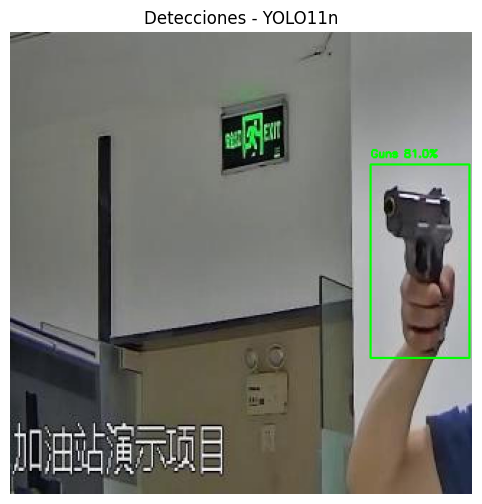

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

DATASET_YAML = path + "/data.yaml"

model_yolo = YOLO("yolo11n.pt")

model_yolo.train(
    data=DATASET_YAML,
    epochs=100,
    imgsz=768,
    batch=16,
    patience=20
)

# Inference
model_yolo = YOLO("runs/detect/train/weights/best.pt")

# Test with an image
IMG_TEST = path + "/valid/images/gun_3_3_1__0003784_jpg.rf.8a25e5f44f10f30054058526ac6e89b4.jpg"
results_yolo = model_yolo(IMG_TEST, conf=0.28)[0]

# Extraer detecciones con porcentaje de confianza
boxes_yolo = []
for box in results_yolo.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])  # <- confianza
    cls = model_yolo.names[cls_id]
    boxes_yolo.append({
        "box": [x1, y1, x2, y2],
        "class": cls,
        "conf": conf
    })

# Visualizar resultados
def mostrar_resultados(img_path, results, framework="YOLO11n"):
    img = cv2.imread(img_path)
    for result in results:
        x1, y1, x2, y2 = map(int, result['box'])
        clase = result['class']
        conf = result['conf']
        label = f"{clase} {conf*100:.1f}%"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detecciones - {framework}")
    plt.axis(False)
    plt.show()

# Mostrar imagen con detecciones
mostrar_resultados(IMG_TEST, boxes_yolo, "YOLO11n")


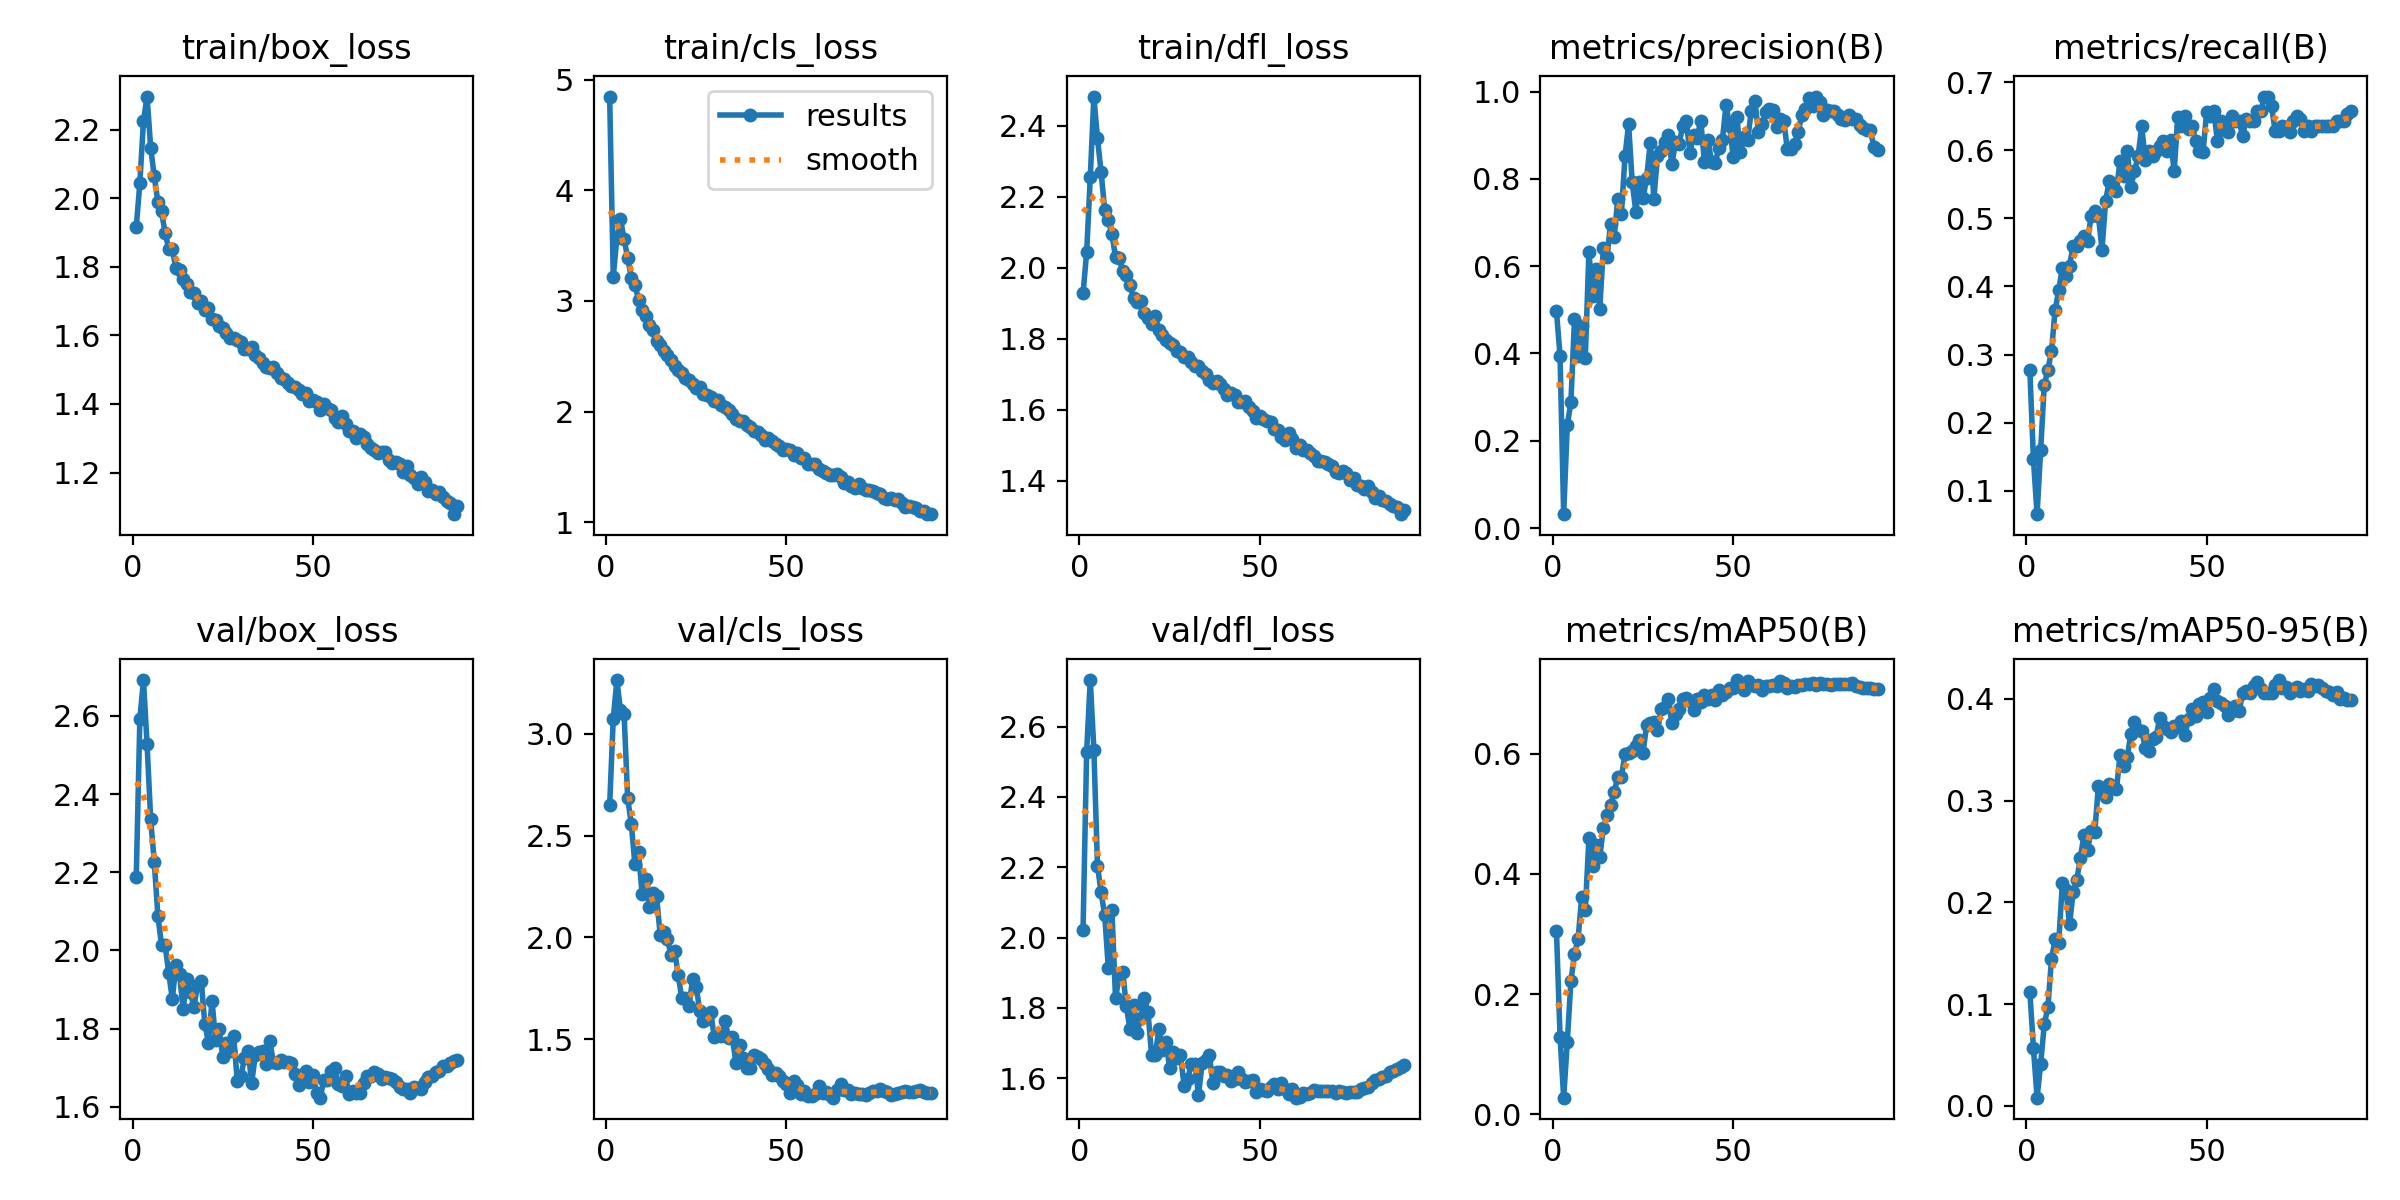

results.png


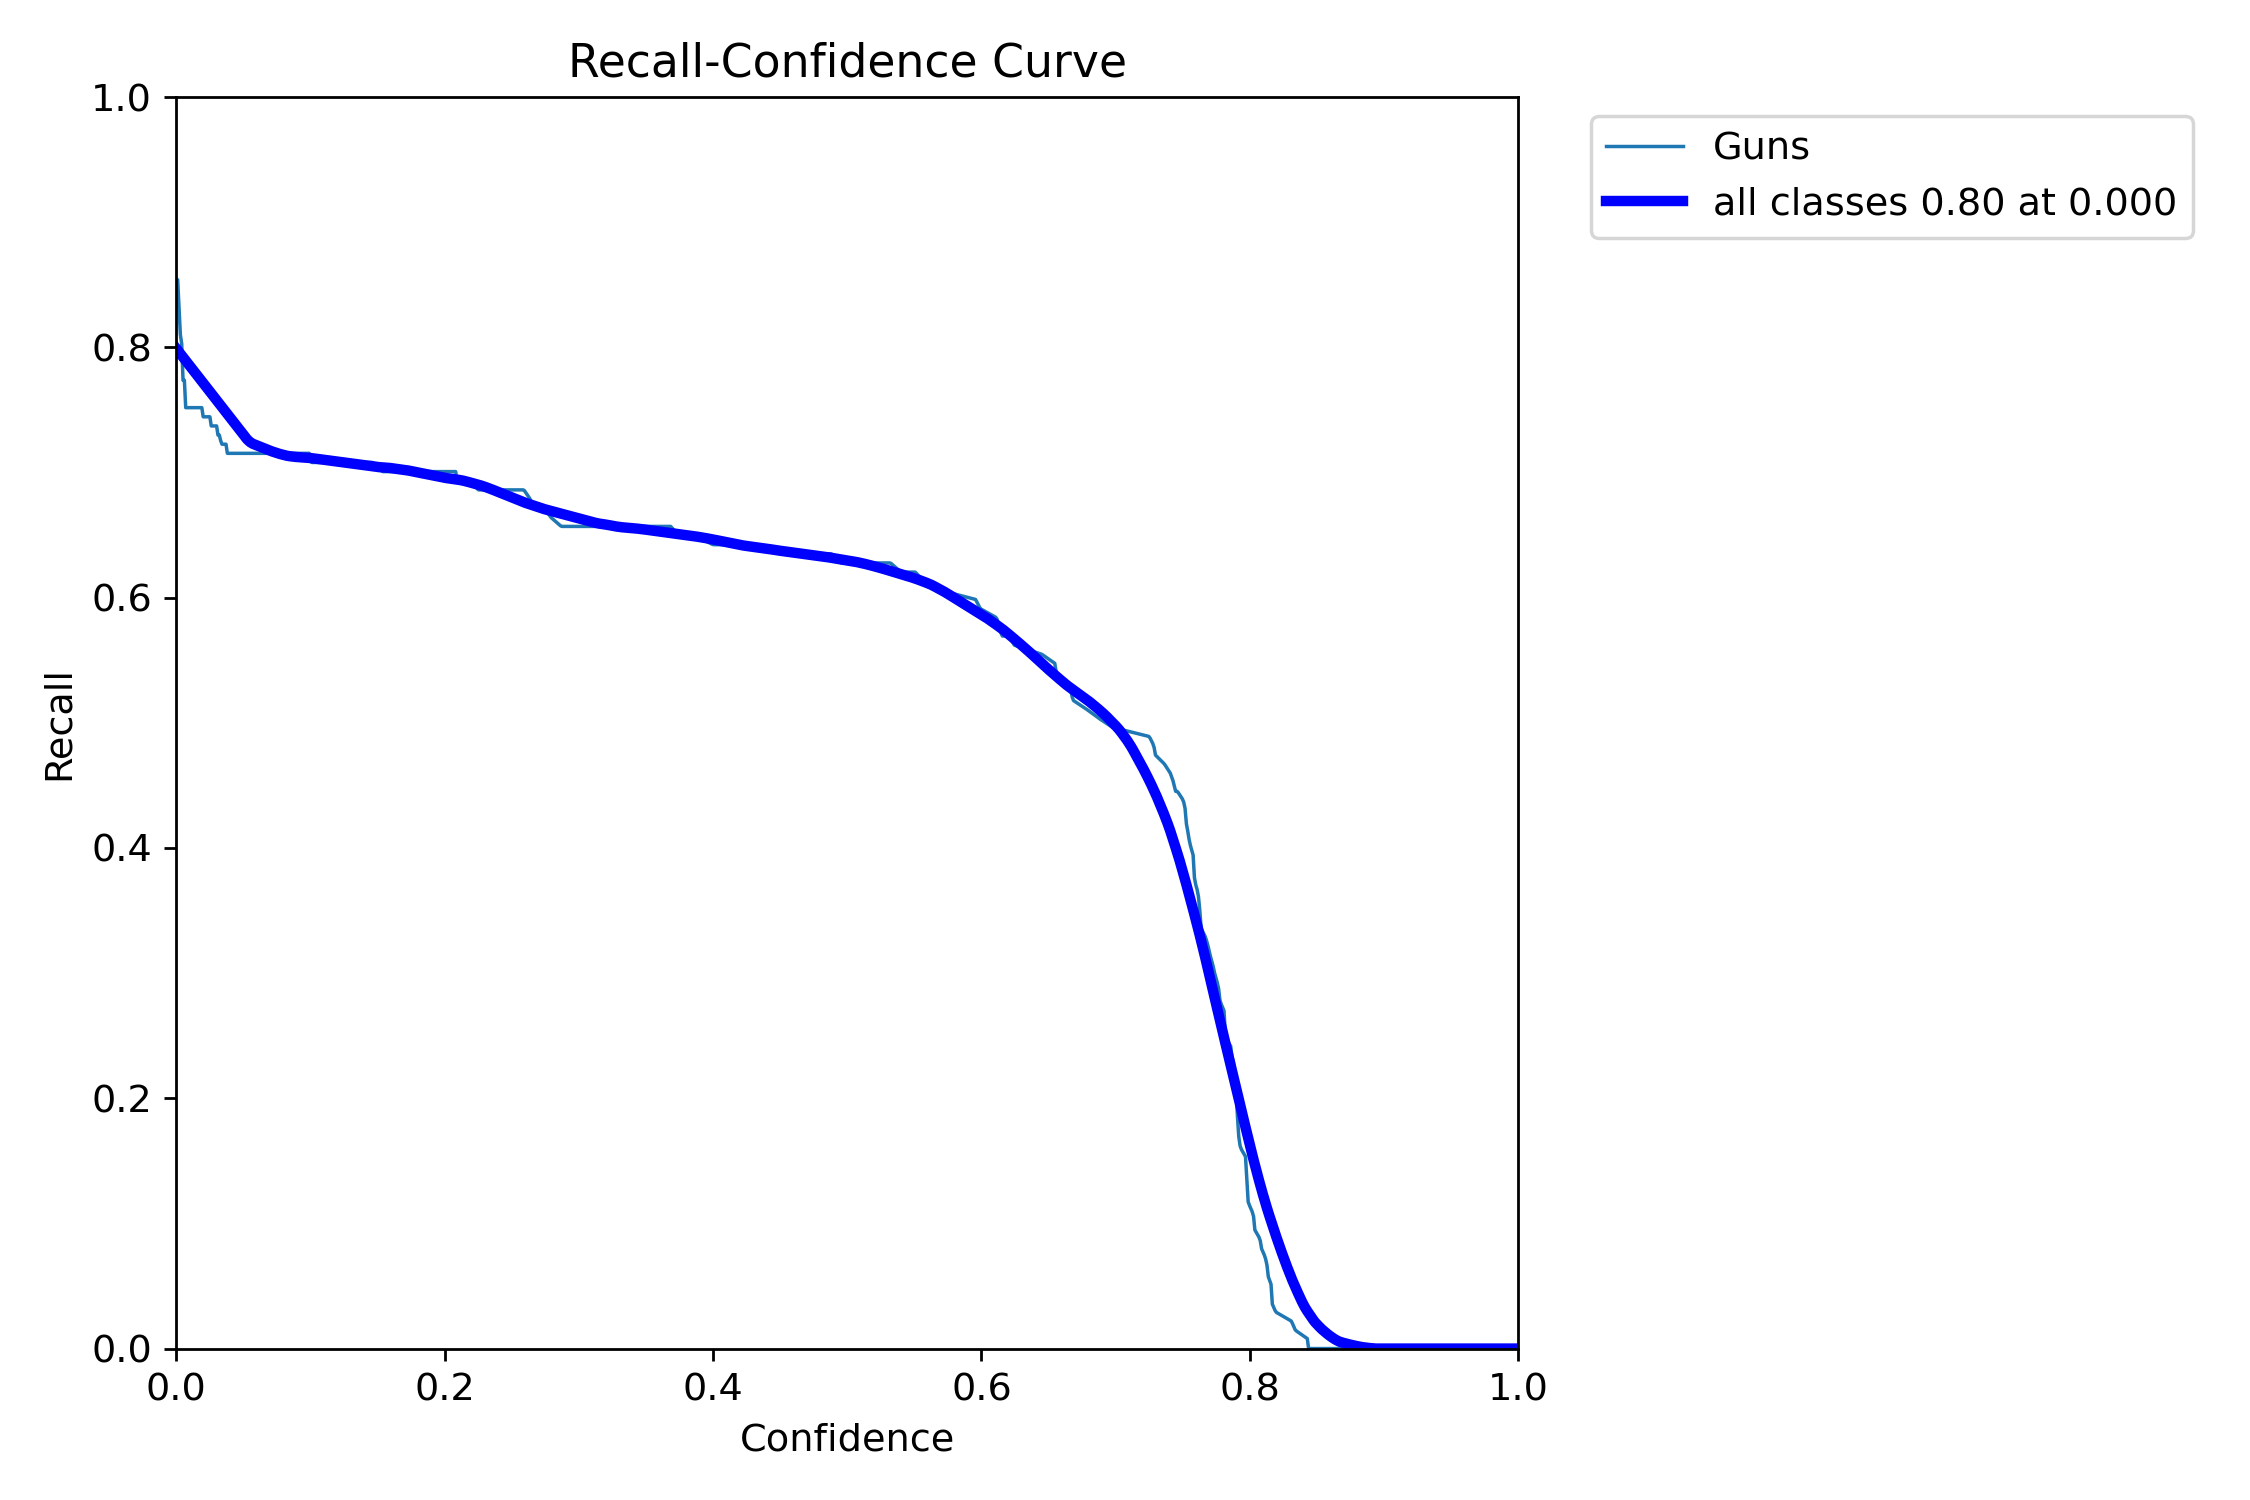

BoxR_curve.png


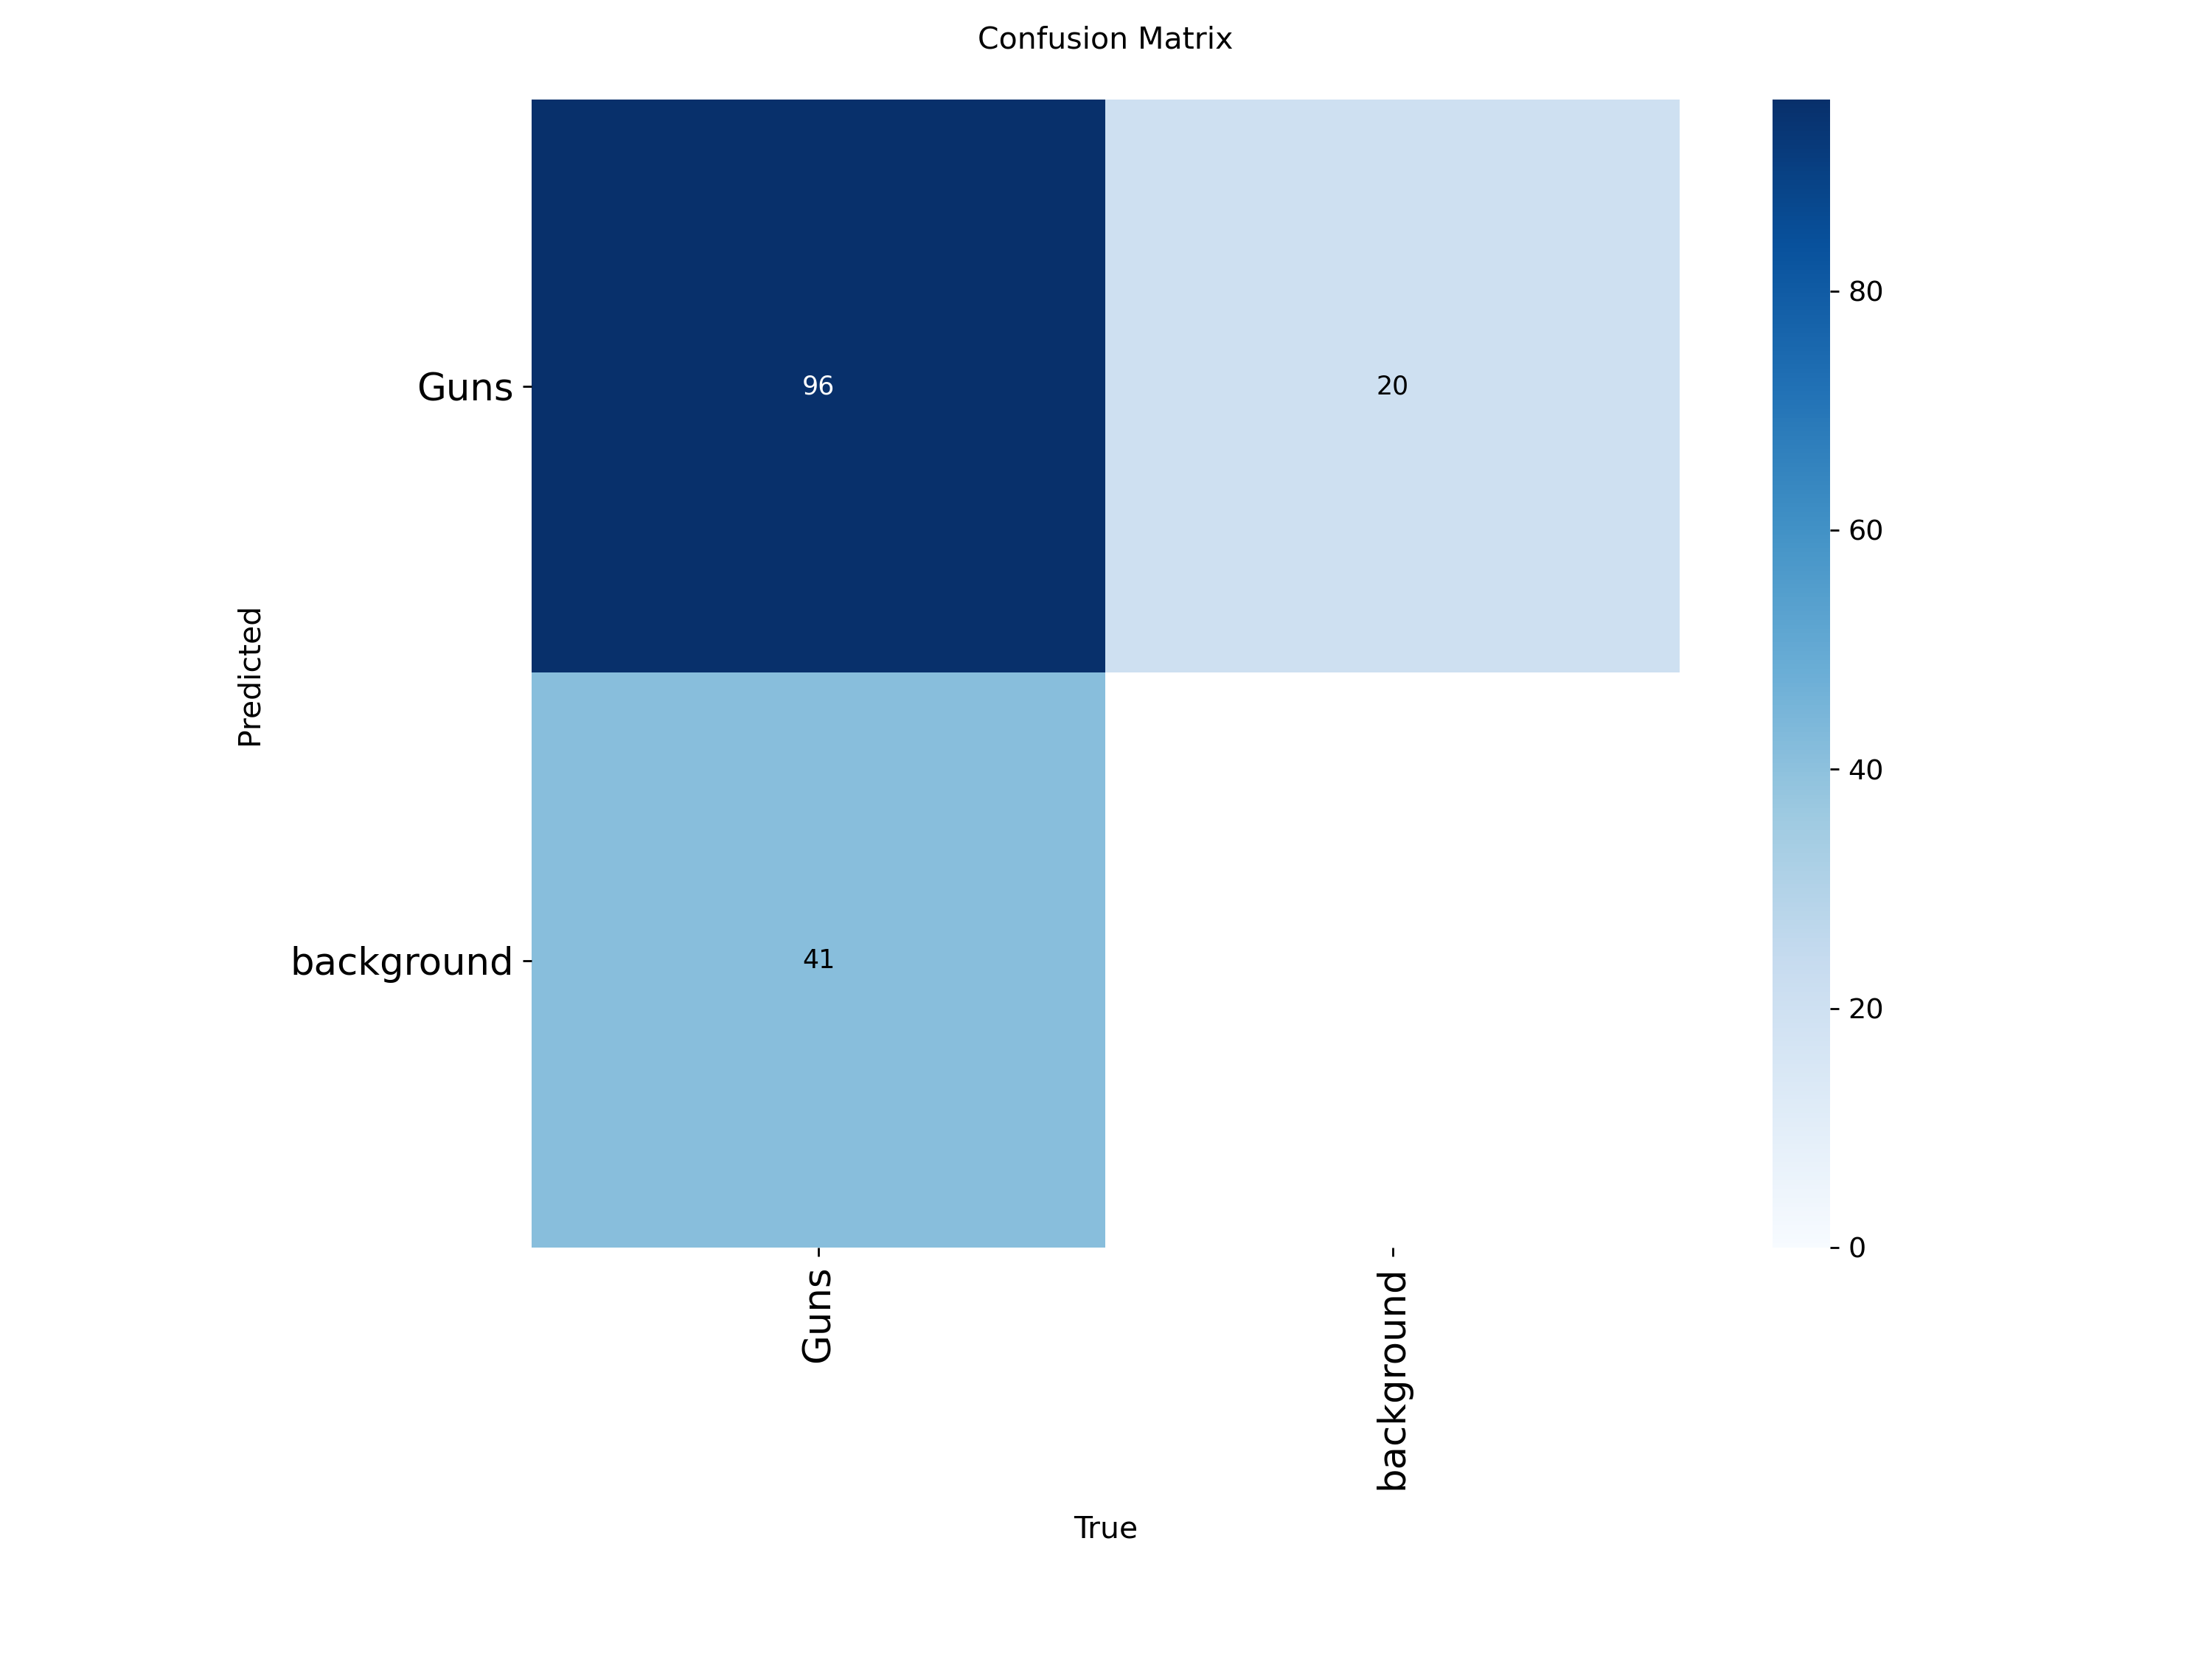

confusion_matrix.png


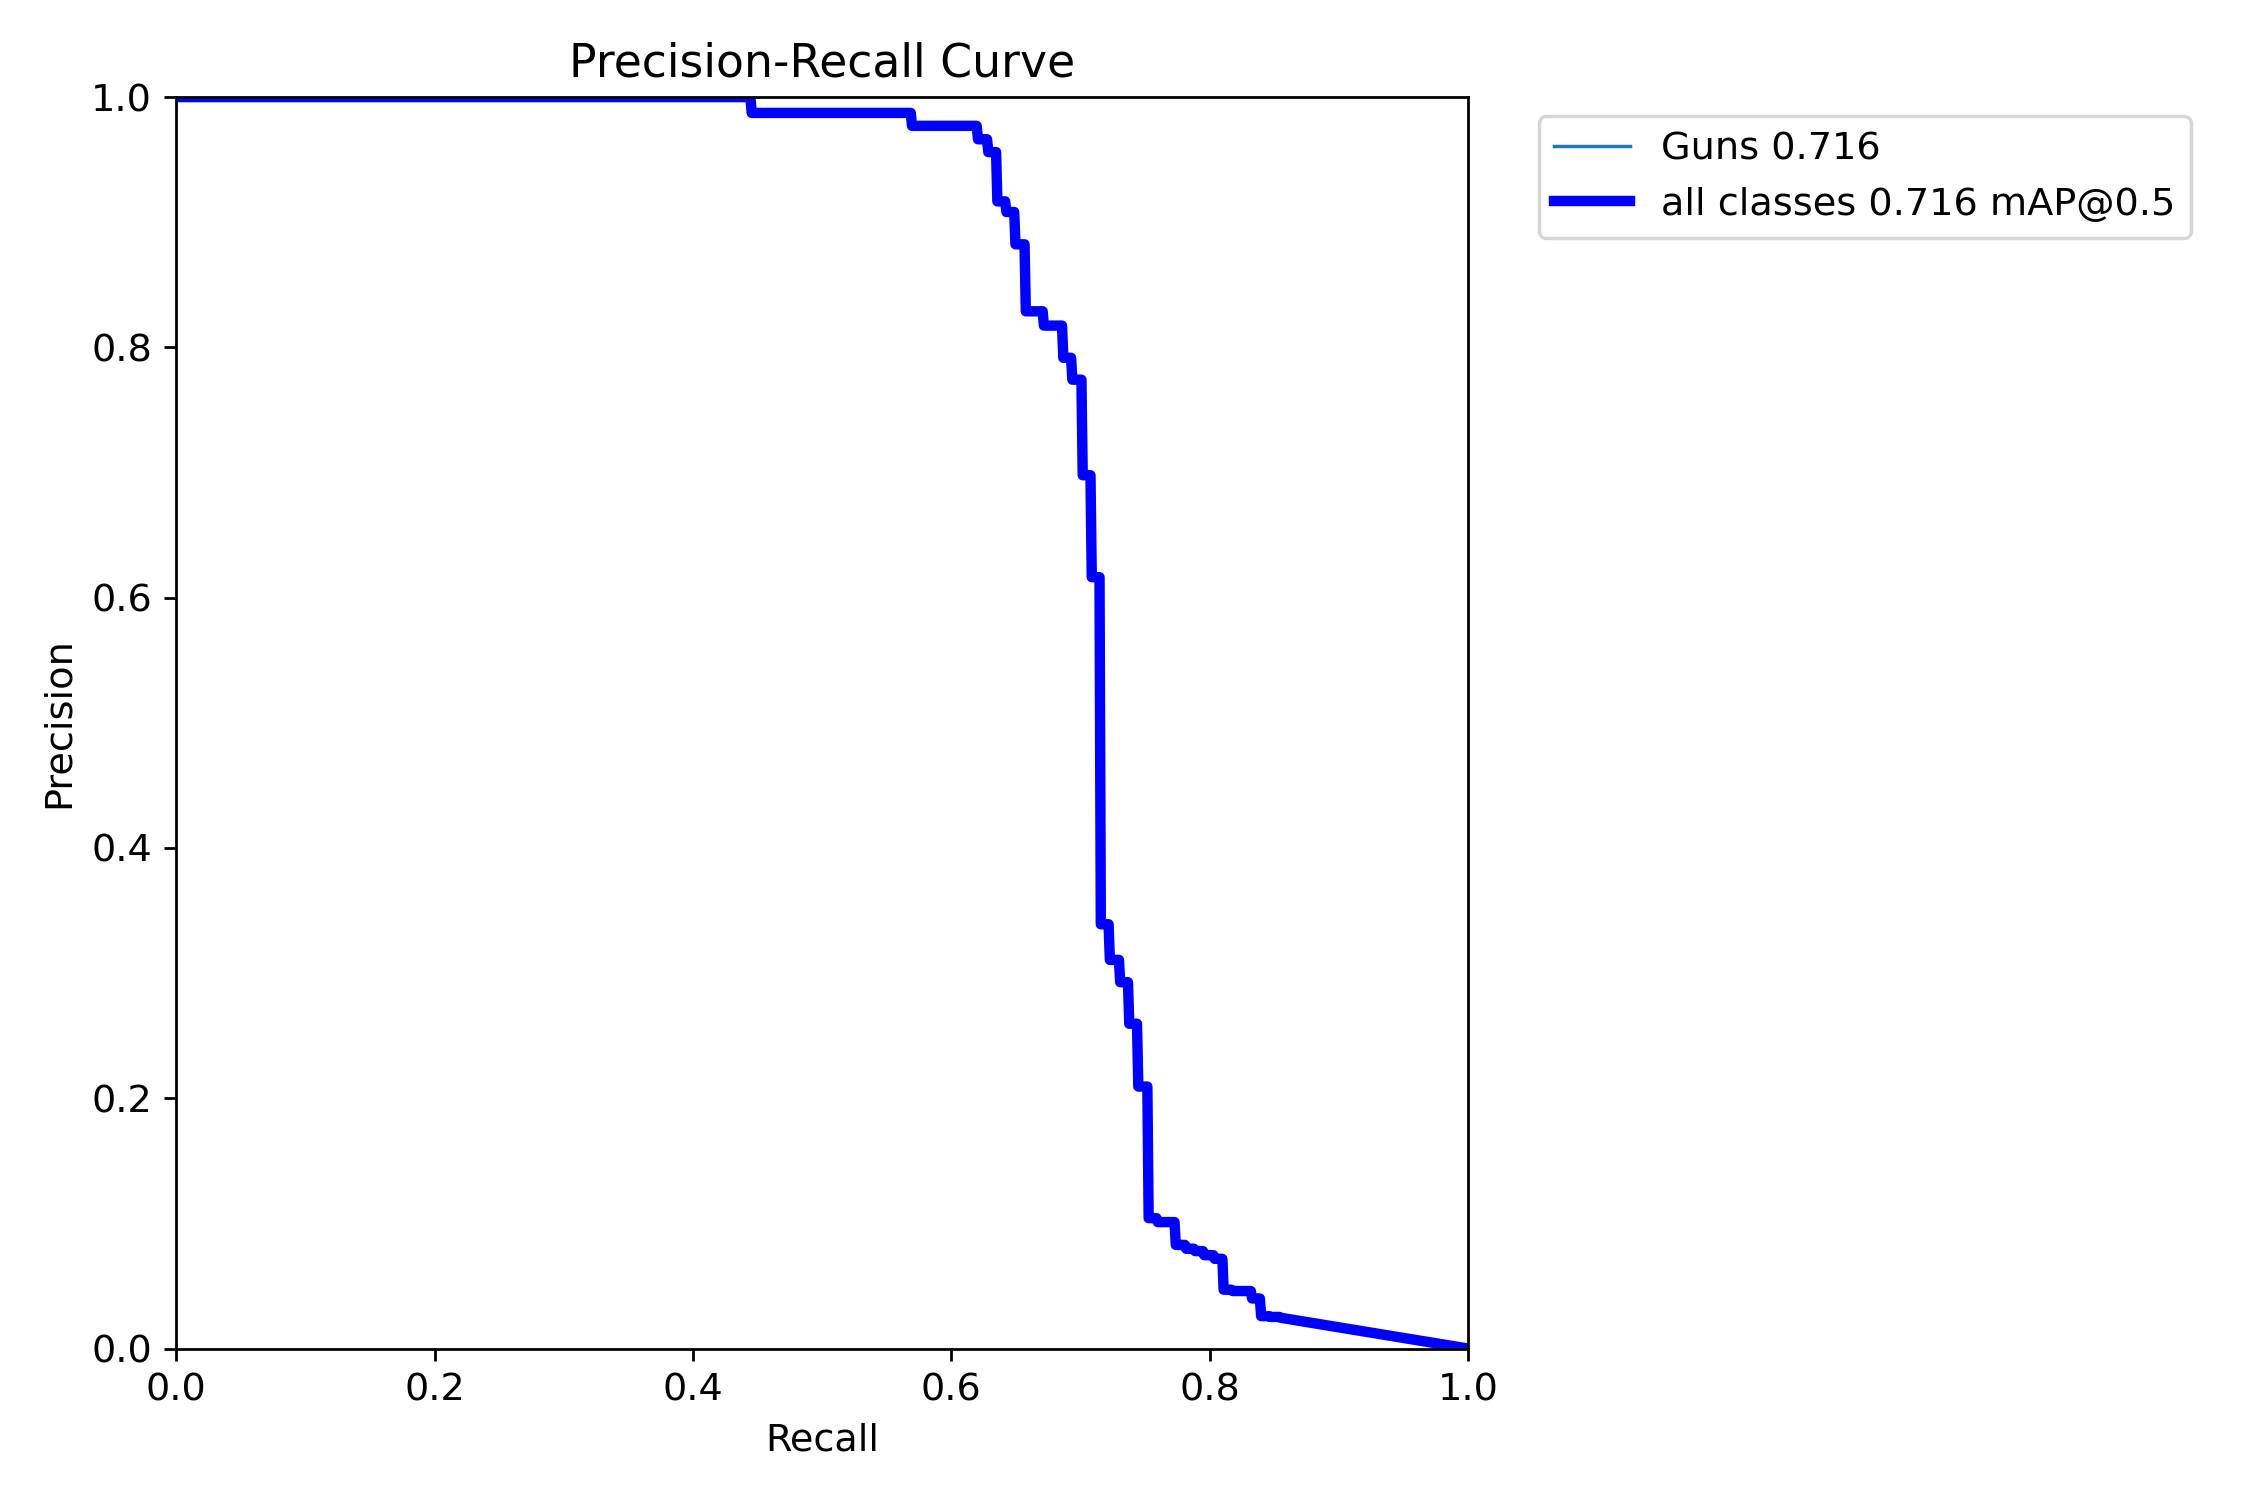

BoxPR_curve.png


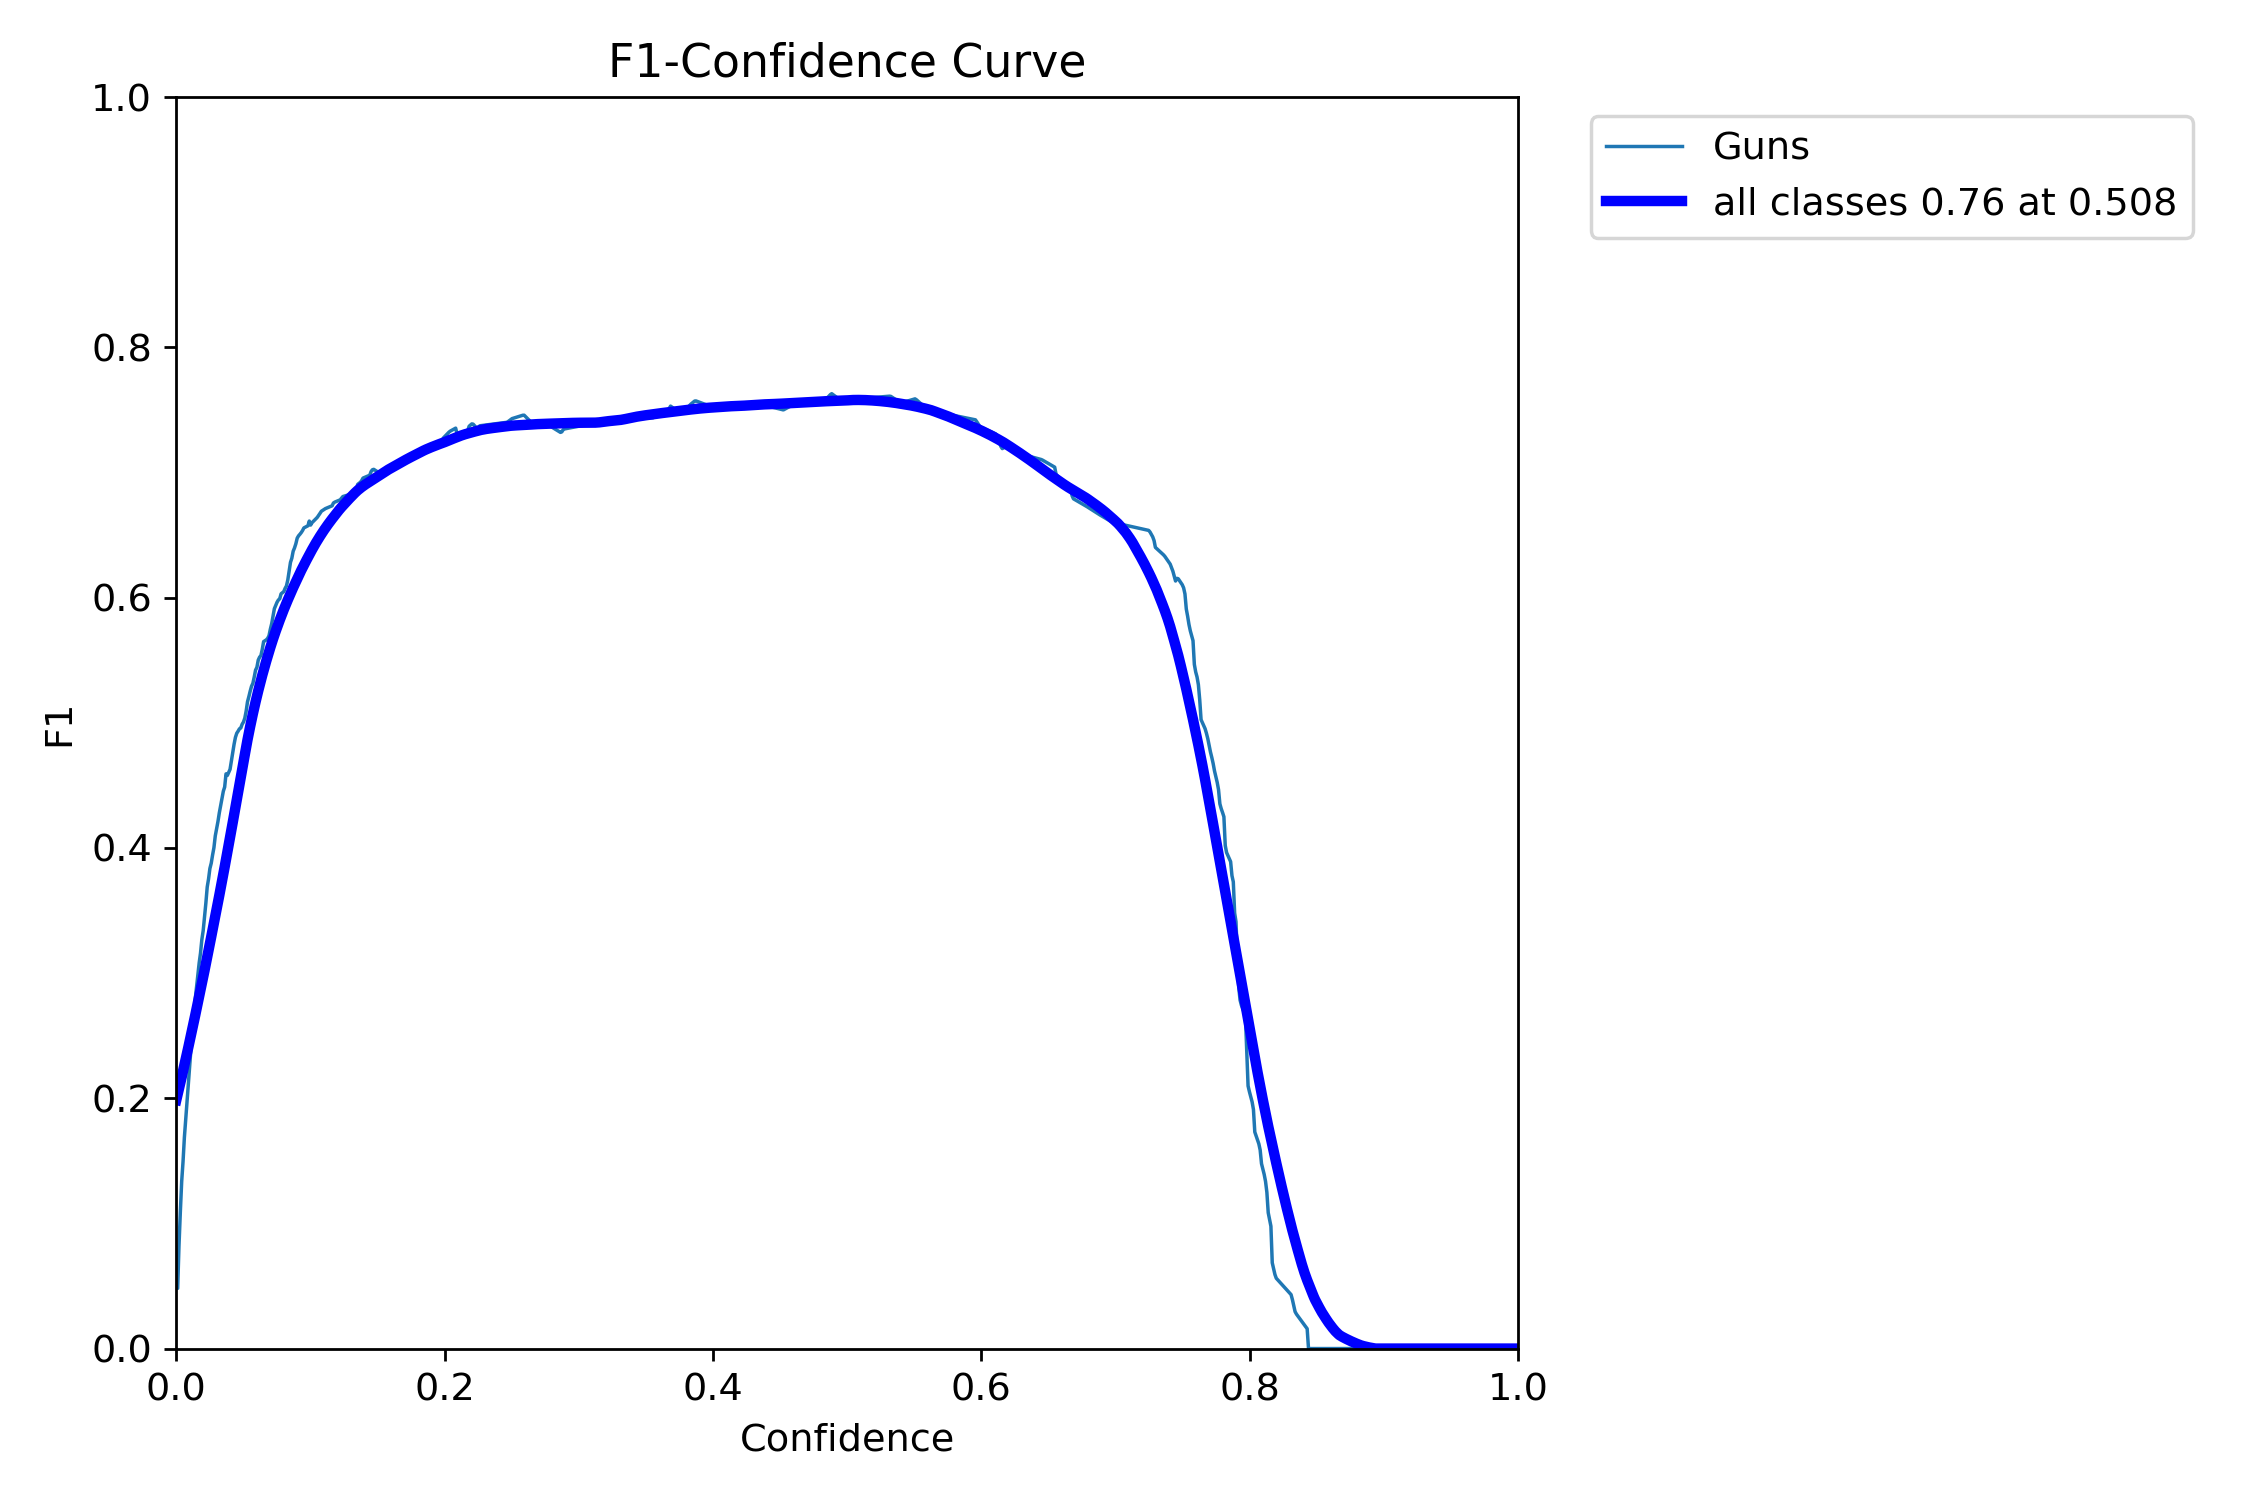

BoxF1_curve.png


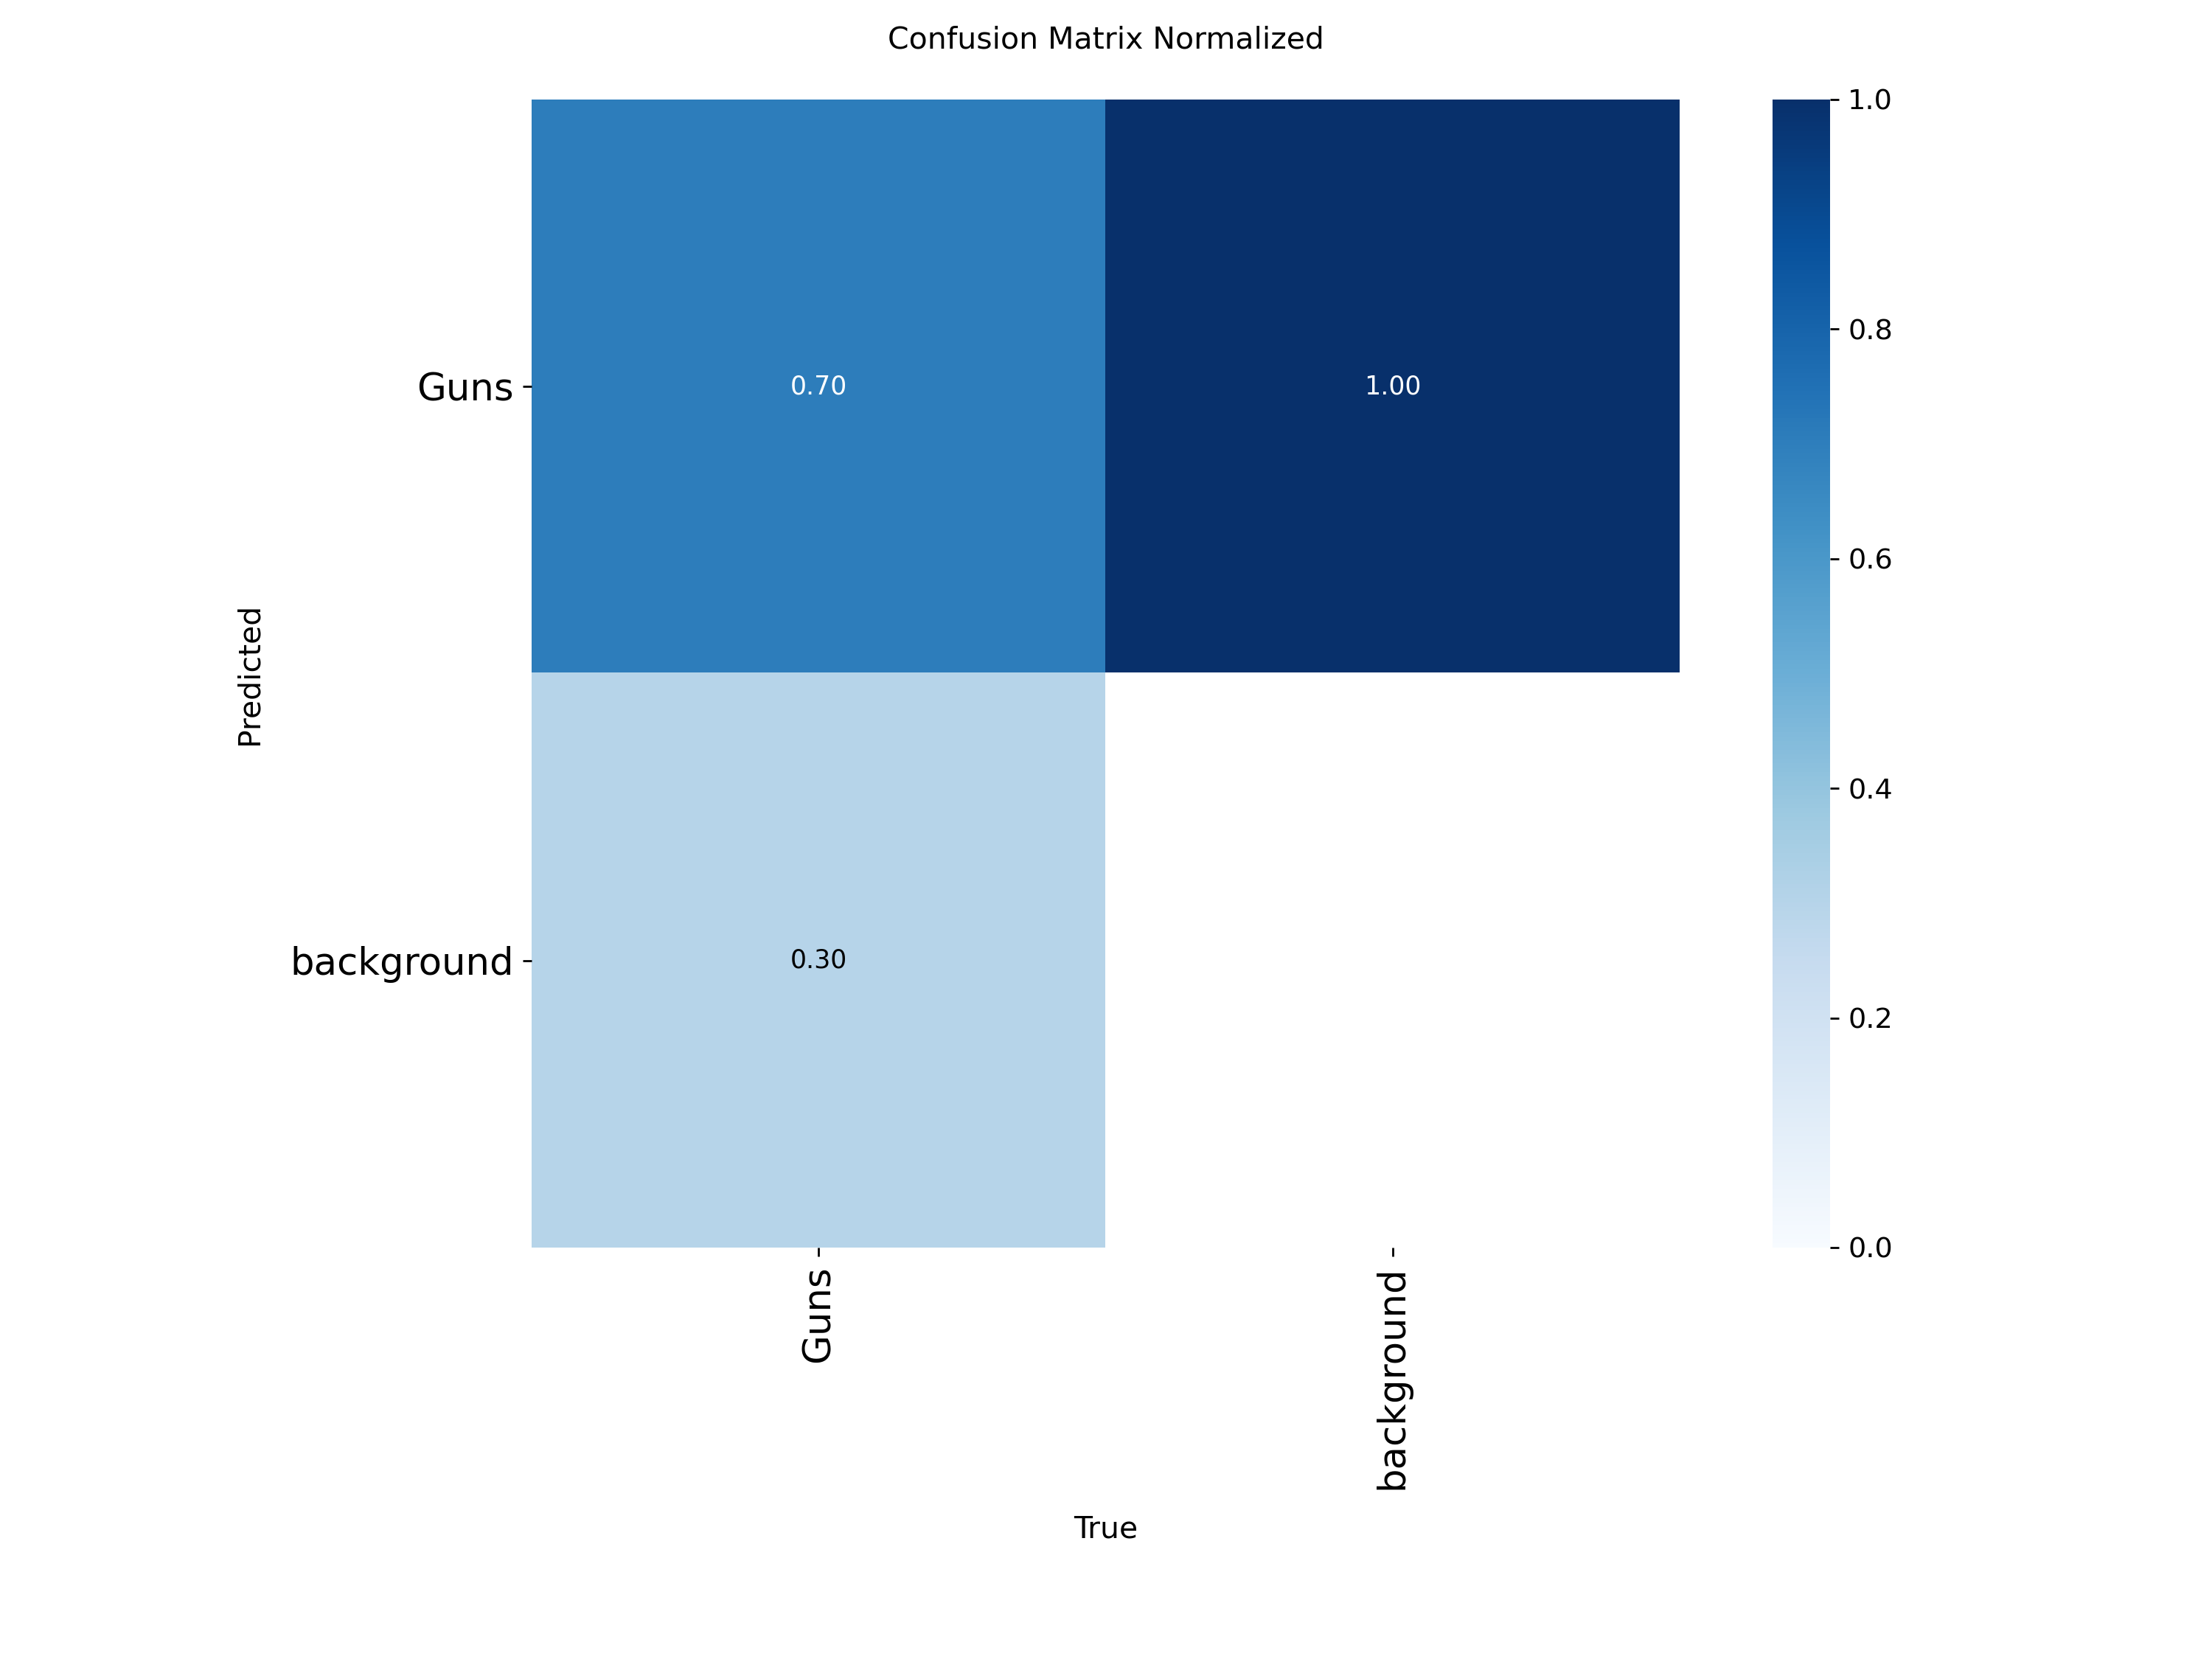

confusion_matrix_normalized.png


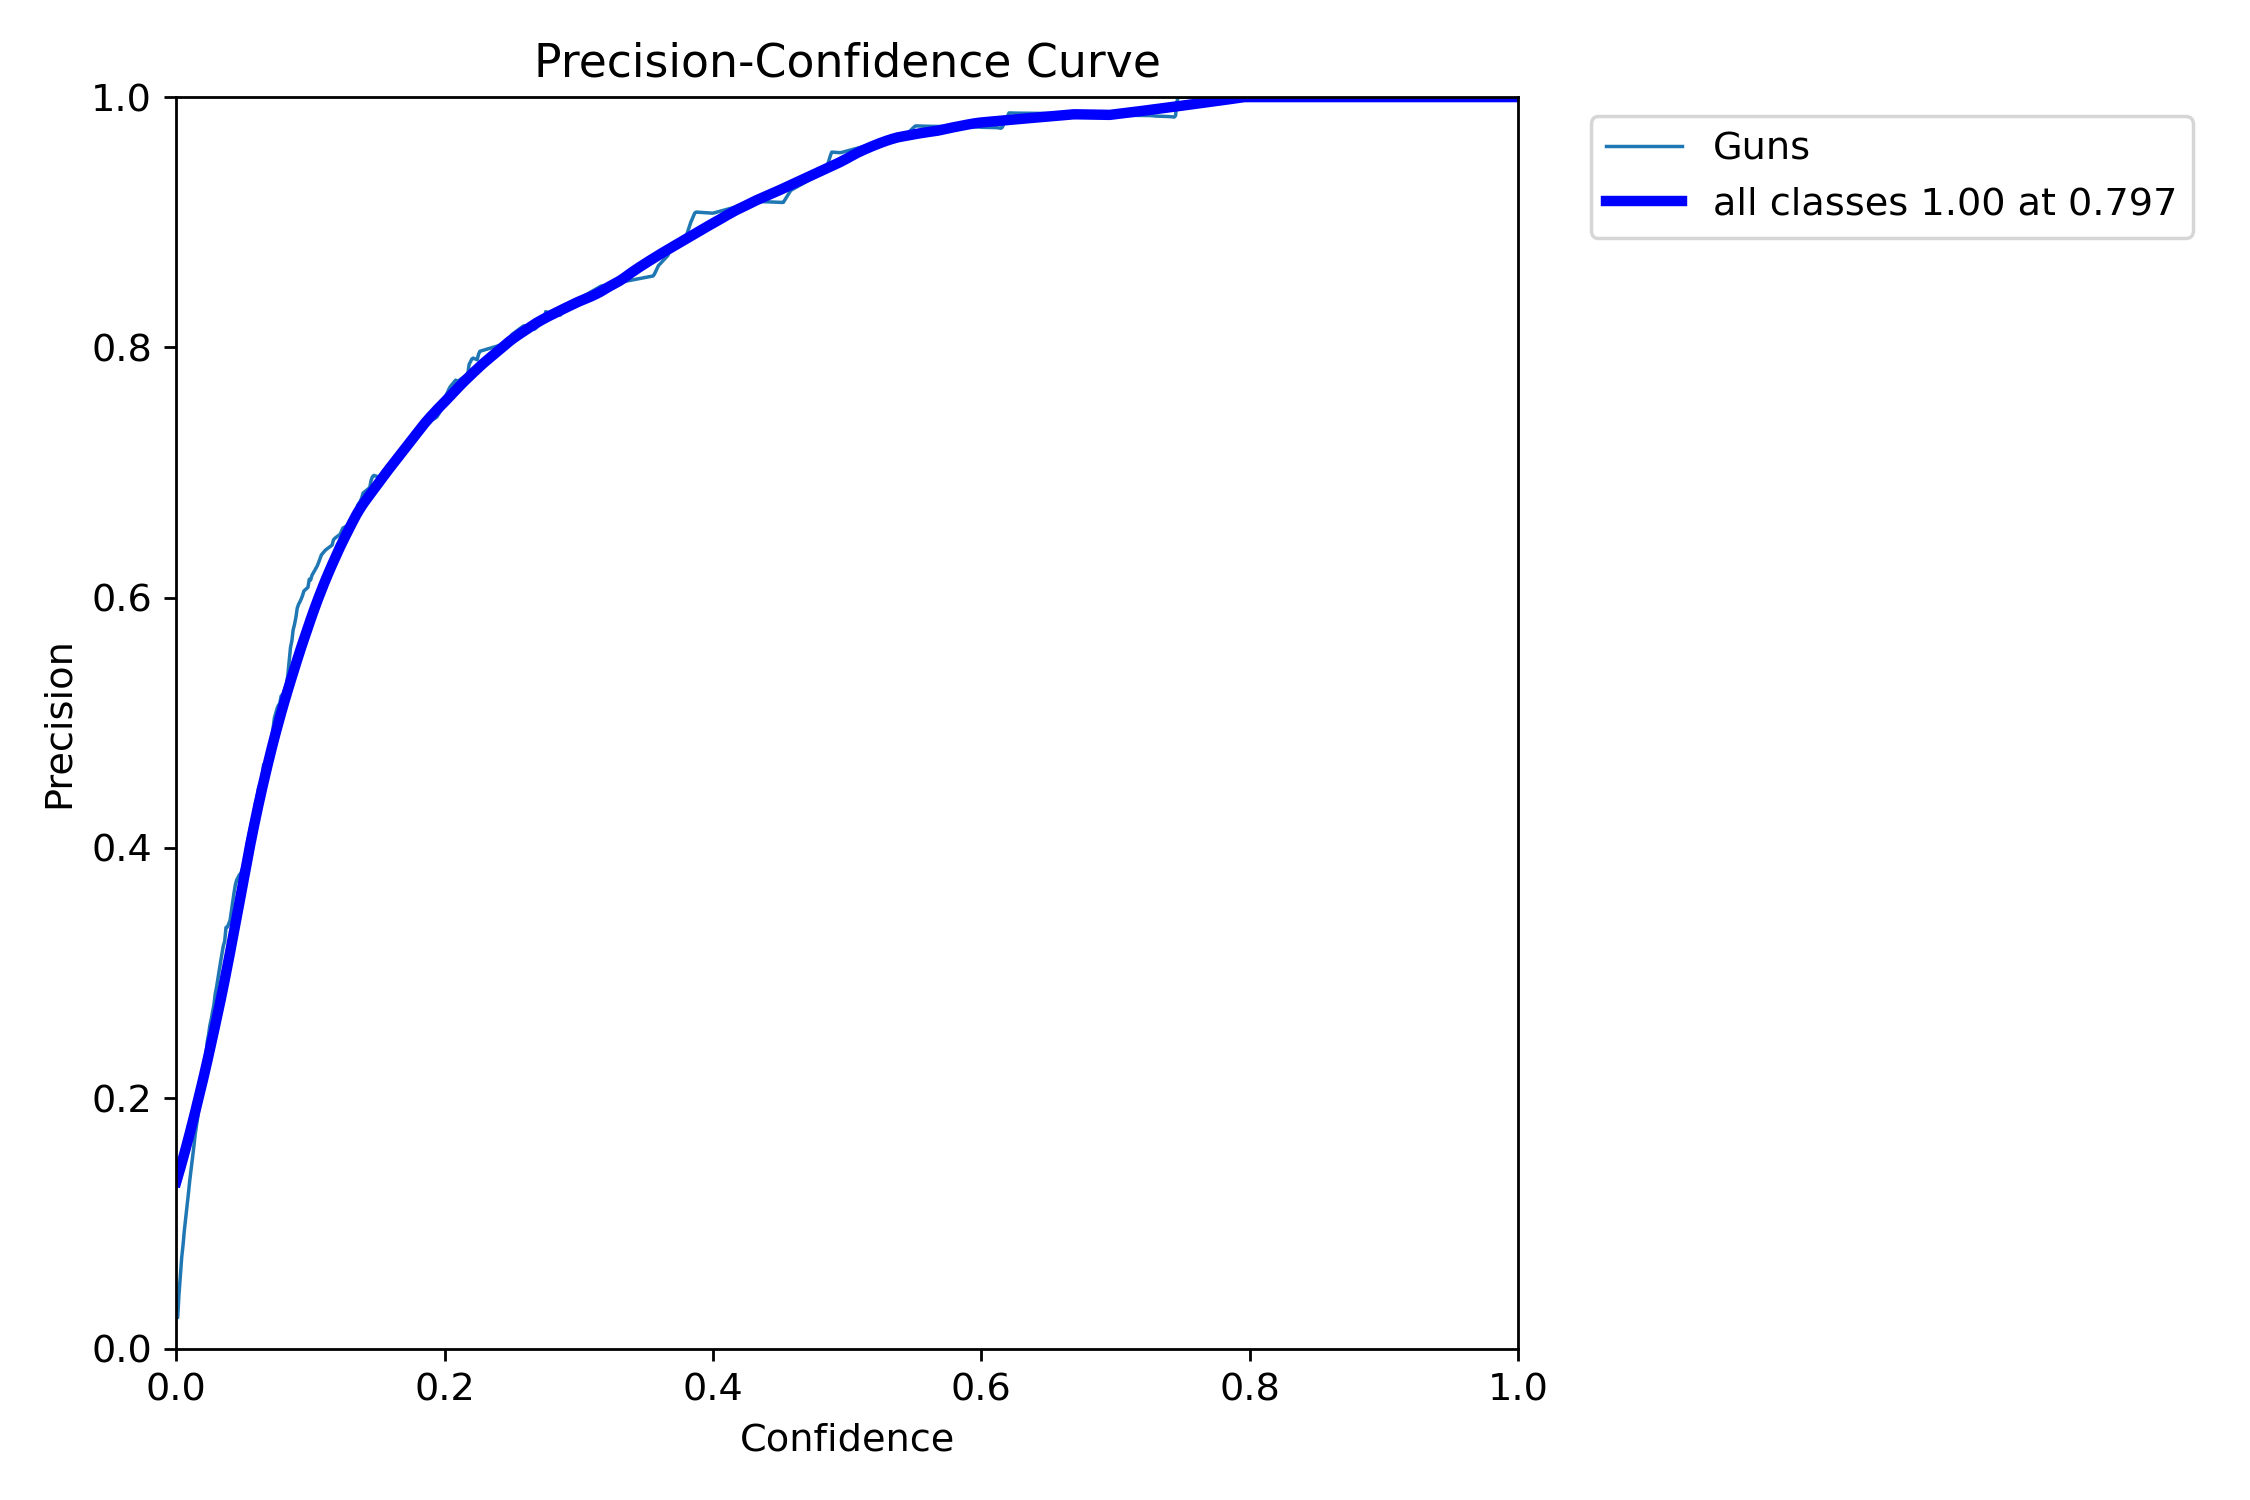

BoxP_curve.png


In [ ]:
import os
from PIL import Image
from IPython.display import display

path_res = "runs/detect/train"

for file in os.listdir(path_res):
    if file.endswith(".png"):
        display(Image.open(os.path.join(path_res, file)))
        print(file)

# Save Metrics and Model Artifacts

In [ ]:
from pathlib import Path
import json
from datetime import datetime

def model_metrics(model, dataset_yaml, drive_folder, run_name="exp"):
    # destino en Drive
    drive_folder = Path(drive_folder)

    # Validar modelo
    metrics = model.val(data=dataset_yaml)

    # Extraer métricas
    mp = float(metrics.box.mp)          # Mean Precision
    mr = float(metrics.box.mr)          # Mean Recall
    map50 = float(metrics.box.map50)    # mAP@0.5
    map95 = float(metrics.box.map)      # mAP@0.5:0.95
    f1 = 2 * (mp * mr) / (mp + mr + 1e-6)

    results = {
        "run_name": run_name,
        "timestamp": datetime.now().isoformat(),
        "precision_mean": mp,
        "recall_mean": mr,
        "f1_score": f1,
        "map_50": map50,
        "map_50_95": map95
    }

    # Display
    print(f"\nMétricas de validación - {run_name}")
    print(f" - Precision media (mp):     {mp:.4f}")
    print(f" - Recall media (mr):        {mr:.4f}")
    print(f" - F1 Score:                 {f1:.4f}")
    print(f" - mAP@0.5:                  {map50:.4f}")
    print(f" - mAP@0.5:0.95:             {map95:.4f}")

    # Guardar JSON
    json_path = drive_folder / f"{run_name}_metrics.json"
    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    # Guardar TXT
    txt_path = drive_folder / f"{run_name}_metrics.txt"
    with open(txt_path, "w") as f:
        f.write(f"Métricas de validación - {run_name}\n")
        f.write(f"Timestamp: {results['timestamp']}\n\n")
        f.write(f"Precision media (mp): {mp:.4f}\n")
        f.write(f"Recall media (mr): {mr:.4f}\n")
        f.write(f"F1 Score: {f1:.4f}\n")
        f.write(f"mAP@0.5: {map50:.4f}\n")
        f.write(f"mAP@0.5:0.95: {map95:.4f}\n")

    print(f"\nArchivos guardados en:")
    print(json_path)
    print(txt_path)

    return results

In [ ]:
from pathlib import Path
import shutil

def save_run_artifacts_to_drive(run_dir, drive_folder, run_name="exp"):
    run_dir = Path(run_dir)
    dest_dir = Path(drive_folder) / run_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    files_to_copy = [
        "results.png",
        "results.csv",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "BoxF1_curve.png",
        "BoxP_curve.png",
        "BoxPR_curve.png",
        "BoxR_curve.png",
        "labels.jpg",
        "args.yaml",
        "weights/best.pt",
        "weights/last.pt",
    ]

    copied = []
    missing = []

    for file_rel in files_to_copy:
        src = run_dir / file_rel
        if src.exists():
            dst = dest_dir / Path(file_rel).name
            shutil.copy2(src, dst)
            copied.append(str(dst))
        else:
            missing.append(str(src))

    print(f"\nArchivos copiados a: {dest_dir}")
    for c in copied:
        print("OK:", c)

    if missing:
        print("\nArchivos no encontrados:")
        for m in missing:
            print(" -", m)

    return dest_dir

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/My_models/Capstone"
best_model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics_dict = model_metrics(
    model=best_model,
    dataset_yaml=DATASET_YAML,
    drive_folder=DRIVE_PATH,
    run_name="yolo11n_100ep_768"
)

RUN_DIR = "/content/runs/detect/train"

save_run_artifacts_to_drive(
    run_dir=RUN_DIR,
    drive_folder=DRIVE_PATH,
    run_name="yolo11n_100ep_768"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1054.0±472.0 MB/s, size: 41.5 KB)
val: Scanning /root/.cache/kagglehub/datasets/abuzarkhaaan/helmetandguntesting/versions/1/Gun with webcam views.v1i.yolov8/valid/labels.cache... 240 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 100.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 137. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/

PosixPath('/content/drive/MyDrive/My_models/Capstone/yolo11n_100ep_768')

# Export

In [ ]:
import shutil

print("Exportando a ONNX...")
onnx_path = best_model.export(format="onnx")

onnx_path = Path(onnx_path)
onnx_drive_path = Path(DRIVE_PATH) / onnx_path.name
shutil.copy2(onnx_path, onnx_drive_path)
print(f"ONNX guardado en: {onnx_drive_path}")

Exportando a ONNX...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 5, 12096) (5.2 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.88...
ONNX: export success ✅ 1.9s, saved as '/content/runs/detect/train/weights/best.onnx' (10.2 MB)

Export complete (2.0s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=768 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=768 data=/root/.cache/kagglehub/datasets/abuzarkhaaan/helmetandguntesting/versions/1/Gun with webcam views.v1i.yolov8/data.yaml  
Visualize:       https://netron.app
ONNX guardado en: /content/drive/MyDrive/My_models/Capstone/best.onnx


# Test Result Metrics

In [11]:
from scipy.sparse import data
import os
import json
import time
import yaml
from pathlib import Path
from statistics import mean, stdev
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test_model_metrics(model_path, dataset, conf=0.28, save_json_path=None):
    # Cargar modelo
    model = YOLO(model_path)

    test_images_path = dataset + "/test/images"
    test_labels_path = dataset + "/test/labels"

    # Obtener lista de archivos de imágenes
    image_files = os.listdir(test_images_path)

    y_true = []
    y_pred = []
    latencies_ms = []

    for img_file in image_files:
        img_path = os.path.join(test_images_path, img_file)

        stem = Path(img_file).stem
        label_path = os.path.join(test_labels_path, stem + ".txt")

        # Ground truth por imagen:
        # 1 = hay al menos un objeto anotado
        # 0 = no hay objetos anotados
        has_object = os.path.exists(label_path) and os.path.getsize(label_path) > 0
        if has_object:
          y_true.append(1)
        else:
          y_true.append(0)

        # Predicción con el threshold real del sistema
        start = time.perf_counter()
        results = model.predict(img_path, conf=conf, verbose=False)
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000.0)

        boxes = results[0].boxes
        pred_has_object = boxes is not None and len(boxes) > 0
        if pred_has_object:
          y_pred.append(1)
        else:
          y_pred.append(0)

    # Métricas por imagen
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    avg_latency = mean(latencies_ms) if latencies_ms else 0.0
    std_latency = stdev(latencies_ms) if len(latencies_ms) > 1 else 0.0

    results_dict = {
        "model_path": model_path,
        "dataset": dataset,
        "test_images_path": test_images_path,
        "test_labels_path": test_labels_path,
        "confidence_threshold": conf,
        "num_test_images": len(image_files),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_latency_ms": avg_latency,
        "std_latency_ms": std_latency,
    }

    print("\nSYSTEM-LEVEL TEST METRICS")
    print(f"Test images:        {len(image_files)}")
    print(f"Confidence:         {conf}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Precision:          {precision:.4f}")
    print(f"Recall:             {recall:.4f}")
    print(f"F1 Score:           {f1:.4f}")
    print(f"Avg latency (ms):   {avg_latency:.2f}")
    print(f"Std latency (ms):   {std_latency:.2f}")

    if save_json_path:
        save_json_path = Path(save_json_path)
        save_json_path.parent.mkdir(parents=True, exist_ok=True)
        with open(save_json_path, "w") as f:
            json.dump(results_dict, f, indent=4)
        print(f"\nJSON guardado en: {save_json_path}")

    return results_dict

The confidence threshold determines the minimum probability required for a detection to be considered valid.
For the following test conf is set to 0.28

In [12]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/My_models/Capstone"
MODEL_PATH = DRIVE_PATH + "/yolo11n_100ep_768/best.pt"

DATASET = path

metrics_system = test_model_metrics(
    model_path=MODEL_PATH,
    dataset=DATASET,
    conf=0.28,
    save_json_path= DRIVE_PATH + "/test_metrics_conf028.json"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

SYSTEM-LEVEL TEST METRICS
Test images:        240
Confidence:         0.28
Accuracy:           0.8583
Precision:          1.0000
Recall:             0.7258
F1 Score:           0.8411
Avg latency (ms):   14.62
Std latency (ms):   3.56

JSON guardado en: /content/drive/MyDrive/My_models/Capstone/test_metrics_conf028.json
